# ЭКЗАМЕНАЦИОННАЯ ЗАДАЧА №02: РАСЧЕТ КРИТИЧЕСКОЙ МАССЫ И ЦЕННОСТИ СОЦИАЛЬНОЙ СЕТИ
# Дата: 2026-09-08
# Студент: Орлова Екатерина Александровна
# Группа: ПИ 4-2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [3]:
print("1. ИСХОДНЫЕ ДАННЫЕ")


# --- 1.1. Параметры проекта ---
print("\n--- 1.1. Параметры проекта ---")

params = {
    'Общий потенциал рынка (M)': 1000000,
    'Начальное число пользователей (N₀)': 5000,
    'Темп прироста до критической массы': 0.03,
    'Темп прироста после критической массы': 0.15,
    'Коэффициент ценности сети (k)': 0.005,
    'Затраты на поддержание в месяц': 2000000,
    'CAC (стоимость привлечения)': 500,
    'ARPU (средний доход с пользователя)': 15,
    'Горизонт (месяцев)': 36,
    'Ставка дисконтирования (мес.)': 0.01
}

df_params = pd.DataFrame([params]).T
df_params.columns = ['Значение']

# Форматирование для отображения
display(df_params)

print("\nИсточник данных: условие задачи (компания 'ГородСоцСеть')")

1. ИСХОДНЫЕ ДАННЫЕ

--- 1.1. Параметры проекта ---


,Значение
Общий потенциал рынка (M),1000000.00
Начальное число пользователей (N₀),5000.00
Темп прироста до критической массы,0.03
Темп прироста после критической массы,0.15
Коэффициент ценности сети (k),0.01
Затраты на поддержание в месяц,2000000.00
CAC (стоимость привлечения),500.00
ARPU (средний доход с пользователя),15.00
Горизонт (месяцев),36.00
Ставка дисконтирования (мес.),0.01



Источник данных: условие задачи (компания 'ГородСоцСеть')


In [4]:
print("\n" + "=" * 80)
print("2. РАСЧЕТЫ")
print("=" * 80)


2. РАСЧЕТЫ


In [5]:
print("\n--- 2.1. Расчет критической массы ---")

# Извлечение параметров
M = params['Общий потенциал рынка (M)']
N0 = params['Начальное число пользователей (N₀)']
growth_before = params['Темп прироста до критической массы']
growth_after = params['Темп прироста после критической массы']
k = params['Коэффициент ценности сети (k)']
maintenance_cost = params['Затраты на поддержание в месяц']
cac = params['CAC (стоимость привлечения)']
arpu = params['ARPU (средний доход с пользователя)']
months = params['Горизонт (месяцев)']
discount_rate = params['Ставка дисконтирования (мес.)']

# Расчет критической массы
# Условие: доход от пользователей >= затраты на поддержание + CAC на новых пользователей
# В точке критической массы: ARPU * N >= maintenance_cost + CAC * (прирост)
# Для упрощения используем условие: доход >= затраты на поддержание

critical_mass = maintenance_cost / arpu
critical_mass = np.ceil(critical_mass)  # Округляем вверх

print(f"\n--- 2.1.1. Критическая масса ---")
print(f"  • Затраты на поддержание в месяц: {maintenance_cost:,.0f} руб.")
print(f"  • ARPU: {arpu} руб./мес.")
print(f"  • Критическая масса (N_крит): {critical_mass:,.0f} пользователей")
print(f"  • Пояснение: при {critical_mass:,.0f} пользователях доход от пользователей покрывает затраты на поддержание")


--- 2.1. Расчет критической массы ---

--- 2.1.1. Критическая масса ---
  • Затраты на поддержание в месяц: 2,000,000 руб.
  • ARPU: 15 руб./мес.
  • Критическая масса (N_крит): 133,334 пользователей
  • Пояснение: при 133,334 пользователях доход от пользователей покрывает затраты на поддержание


In [6]:
print("\n--- 2.1.2. Расчет времени достижения критической массы ---")

# Моделирование роста пользователей
N = N0
users = [N]
months_to_critical = 0
month = 0

while N < critical_mass and month < months:
    month += 1
    N = N * (1 + growth_before)
    users.append(N)
    if N >= critical_mass:
        months_to_critical = month
        break

# Если не достигли за 36 месяцев
if months_to_critical == 0:
    months_to_critical = months

print(f"  • Начальное число пользователей: {N0:,.0f} чел.")
print(f"  • Ежемесячный прирост до критической массы: {growth_before * 100:.0f}%")
print(f"  • Критическая масса: {critical_mass:,.0f} пользователей")
print(f"  • Месяцев до достижения критической массы: {months_to_critical} мес.")
print(f"  • Число пользователей в момент достижения: {users[-1]:,.0f} чел.")


--- 2.1.2. Расчет времени достижения критической массы ---
  • Начальное число пользователей: 5,000 чел.
  • Ежемесячный прирост до критической массы: 3%
  • Критическая масса: 133,334 пользователей
  • Месяцев до достижения критической массы: 36 мес.
  • Число пользователей в момент достижения: 14,491 чел.


In [7]:
print("\n--- 2.2. Оценка ценности сети по закону Мэткалфа ---")

# Создаем DataFrame для всех месяцев
df = pd.DataFrame()
df['Месяц'] = range(0, months + 1)

# Расчет числа пользователей по месяцам
users_list = [N0]
growth_rates = []

for month in range(1, months + 1):
    current_users = users_list[-1]
    if current_users < critical_mass:
        growth = growth_before
    else:
        growth = growth_after
    new_users = current_users * (1 + growth)
    users_list.append(new_users)
    growth_rates.append(growth)

df['Пользователи (N)'] = users_list

# 2.2.1. Ценность сети по закону Мэткалфа
df['Ценность сети (V)'] = k * df['Пользователи (N)'] ** 2

# 2.2.2. Доход от пользователей
df['Доход (R)'] = arpu * df['Пользователи (N)']

# 2.2.3. Новые пользователи и затраты на привлечение
df['Новые пользователи'] = df['Пользователи (N)'].diff().fillna(0)
df['Затраты на привлечение (CAC)'] = df['Новые пользователи'] * cac

# 2.2.4. Прибыль
df['Затраты на поддержание'] = maintenance_cost
df['Прибыль (П)'] = df['Доход (R)'] - df['Затраты на поддержание'] - df['Затраты на привлечение (CAC)']

# Вывод первых и последних строк
print("\n--- 2.2.1. Ценность сети по закону Мэткалфа ---")
print(f"  • Формула: V(N) = k × N², где k = {k} руб./пользователь²")
print(f"  • Пример: при 100 000 пользователей ценность сети = {k * 100000**2:,.0f} руб.")

print("\n--- 2.2.2. Доход от пользователей ---")
print(f"  • Формула: R(N) = ARPU × N, где ARPU = {arpu} руб./мес.")
print(f"  • Пример: при 100 000 пользователей доход = {arpu * 100000:,.0f} руб./мес.")

print("\n--- 2.2.3. Затраты на привлечение ---")
print(f"  • CAC = {cac} руб. на одного нового пользователя")
print(f"  • Затраты на поддержание: {maintenance_cost:,.0f} руб./мес.")

print("\n--- 2.2.4. Прибыль ---")
print(f"  • Формула: П(N) = R(N) - Затраты на поддержание - CAC × Новые пользователи")
print(f"  • Прибыль в месяц 36: {df.iloc[-1]['Прибыль (П)']:,.0f} руб.")


--- 2.2. Оценка ценности сети по закону Мэткалфа ---

--- 2.2.1. Ценность сети по закону Мэткалфа ---
  • Формула: V(N) = k × N², где k = 0.005 руб./пользователь²
  • Пример: при 100 000 пользователей ценность сети = 50,000,000 руб.

--- 2.2.2. Доход от пользователей ---
  • Формула: R(N) = ARPU × N, где ARPU = 15 руб./мес.
  • Пример: при 100 000 пользователей доход = 1,500,000 руб./мес.

--- 2.2.3. Затраты на привлечение ---
  • CAC = 500 руб. на одного нового пользователя
  • Затраты на поддержание: 2,000,000 руб./мес.

--- 2.2.4. Прибыль ---
  • Формула: П(N) = R(N) - Затраты на поддержание - CAC × Новые пользователи
  • Прибыль в месяц 36: -1,993,669 руб.



--- 2.3. Визуализация динамики ---


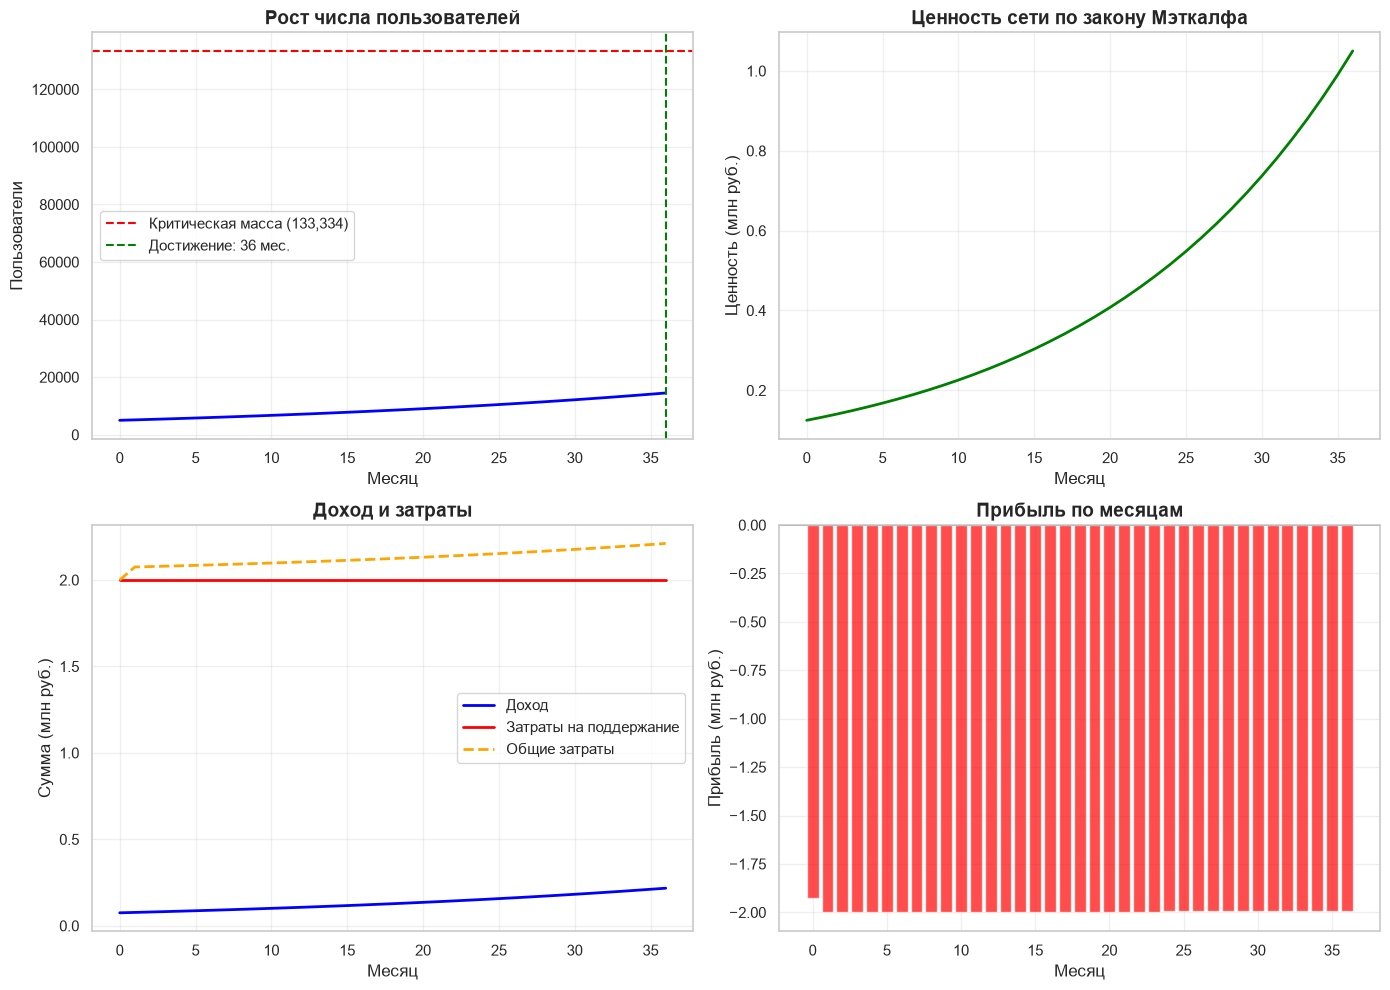

✅ График сохранен в reports/task_02_social_network_analysis.png


In [8]:
print("\n--- 2.3. Визуализация динамики ---")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Рост числа пользователей
ax1 = axes[0, 0]
ax1.plot(df['Месяц'], df['Пользователи (N)'], linewidth=2, color='blue')
ax1.axhline(y=critical_mass, color='red', linestyle='--', linewidth=1.5, label=f'Критическая масса ({critical_mass:,.0f})')
ax1.axvline(x=months_to_critical, color='green', linestyle='--', linewidth=1.5, label=f'Достижение: {months_to_critical} мес.')
ax1.set_title('Рост числа пользователей', fontsize=14, fontweight='bold')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Пользователи')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Ценность сети (закон Мэткалфа)
ax2 = axes[0, 1]
ax2.plot(df['Месяц'], df['Ценность сети (V)'] / 1e6, linewidth=2, color='green')
ax2.set_title('Ценность сети по закону Мэткалфа', fontsize=14, fontweight='bold')
ax2.set_xlabel('Месяц')
ax2.set_ylabel('Ценность (млн руб.)')
ax2.grid(True, alpha=0.3)

# 3. Доход и затраты
ax3 = axes[1, 0]
ax3.plot(df['Месяц'], df['Доход (R)'] / 1e6, linewidth=2, color='blue', label='Доход')
ax3.plot(df['Месяц'], df['Затраты на поддержание'] / 1e6, linewidth=2, color='red', label='Затраты на поддержание')
ax3.plot(df['Месяц'], (df['Затраты на поддержание'] + df['Затраты на привлечение (CAC)']) / 1e6,
         linewidth=2, color='orange', linestyle='--', label='Общие затраты')
ax3.set_title('Доход и затраты', fontsize=14, fontweight='bold')
ax3.set_xlabel('Месяц')
ax3.set_ylabel('Сумма (млн руб.)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Прибыль
ax4 = axes[1, 1]
colors = ['green' if x > 0 else 'red' for x in df['Прибыль (П)']]
ax4.bar(df['Месяц'], df['Прибыль (П)'] / 1e6, color=colors, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_title('Прибыль по месяцам', fontsize=14, fontweight='bold')
ax4.set_xlabel('Месяц')
ax4.set_ylabel('Прибыль (млн руб.)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/task_02_social_network_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ График сохранен в reports/task_02_social_network_analysis.png")

In [9]:
print("\n--- 2.4. Расчет NPV проекта ---")

# Расчет дисконтированных денежных потоков
df['Дисконтированная прибыль'] = df['Прибыль (П)'] / ((1 + discount_rate) ** df['Месяц'])

# NPV = сумма дисконтированных потоков (исключая месяц 0)
npv = df.iloc[1:]['Дисконтированная прибыль'].sum()

print(f"  • Ставка дисконтирования: {discount_rate * 100:.1f}% в месяц (12% годовых)")
print(f"  • Горизонт: {months} месяцев")
print(f"  • NPV проекта: {npv:,.0f} руб.")
print(f"  • Суммарная прибыль (без дисконтирования): {df['Прибыль (П)'].sum():,.0f} руб.")

if npv > 0:
    print(f"  • Результат: ✅ Проект экономически эффективен (NPV > 0)")
else:
    print(f"  • Результат: ❌ Проект экономически неэффективен (NPV < 0)")


--- 2.4. Расчет NPV проекта ---
  • Ставка дисконтирования: 1.0% в месяц (12% годовых)
  • Горизонт: 36 месяцев
  • NPV проекта: -60,099,621 руб.
  • Суммарная прибыль (без дисконтирования): -73,782,629 руб.
  • Результат: ❌ Проект экономически неэффективен (NPV < 0)


In [10]:
print("\n" + "=" * 80)
print("3. АНАЛИЗ ЭФФЕКТИВНОСТИ")
print("=" * 80)


3. АНАЛИЗ ЭФФЕКТИВНОСТИ


In [11]:
print("\n--- 3.1. Анализ чувствительности ---")

# Сценарии
scenarios = {
    'Базовый': {'before': 0.03, 'after': 0.15},
    'Пессимистичный': {'before': 0.02, 'after': 0.10},
    'Оптимистичный': {'before': 0.05, 'after': 0.20}
}

results = {}

for name, rates in scenarios.items():
    # Моделируем рост для каждого сценария
    users_scenario = [N0]
    critical_month = 0

    for month in range(1, months + 1):
        current = users_scenario[-1]
        if current < critical_mass:
            growth = rates['before']
        else:
            growth = rates['after']
        users_scenario.append(current * (1 + growth))

        if current < critical_mass and users_scenario[-1] >= critical_mass and critical_month == 0:
            critical_month = month

    # Расчет финансовых показателей
    df_scenario = pd.DataFrame()
    df_scenario['Пользователи'] = users_scenario
    df_scenario['Доход'] = arpu * df_scenario['Пользователи']
    df_scenario['Новые пользователи'] = df_scenario['Пользователи'].diff().fillna(0)
    df_scenario['Затраты CAC'] = df_scenario['Новые пользователи'] * cac
    df_scenario['Затраты поддержание'] = maintenance_cost
    df_scenario['Прибыль'] = df_scenario['Доход'] - df_scenario['Затраты поддержание'] - df_scenario['Затраты CAC']
    df_scenario['Дисконтированная прибыль'] = df_scenario['Прибыль'] / ((1 + discount_rate) ** df_scenario.index)

    npv_scenario = df_scenario.iloc[1:]['Дисконтированная прибыль'].sum()
    final_users = users_scenario[-1]

    results[name] = {
        'Сценарий': name,
        'Темп до критической': f"{rates['before'] * 100:.0f}%",
        'Темп после критической': f"{rates['after'] * 100:.0f}%",
        'Месяц достижения критической': critical_month if critical_month > 0 else '>36',
        'Конечное число пользователей': f"{final_users:,.0f}",
        'NPV': f"{npv_scenario:,.0f} руб."
    }

df_scenarios = pd.DataFrame(results).T
print("--- 3.1.1. Сравнение сценариев ---")
display(df_scenarios)


--- 3.1. Анализ чувствительности ---
--- 3.1.1. Сравнение сценариев ---


,Сценарий,Темп до критической,Темп после критической,Месяц достижения критической,Конечное число пользователей,NPV
Базовый,Базовый,3%,15%,>36,"14,491","-60,099,621 руб."
Пессимистичный,Пессимистичный,2%,10%,>36,"10,199","-59,086,830 руб."
Оптимистичный,Оптимистичный,5%,20%,>36,"28,959","-63,739,312 руб."



--- 3.2. Определение минимального ARPU ---
  • Проект не достигает безубыточности в диапазоне ARPU от 5 до 30 руб.
  • Требуется пересмотр бизнес-модели или снижение затрат

  • Текущий ARPU: 15 руб./мес.
  • Проект убыточен при текущем ARPU


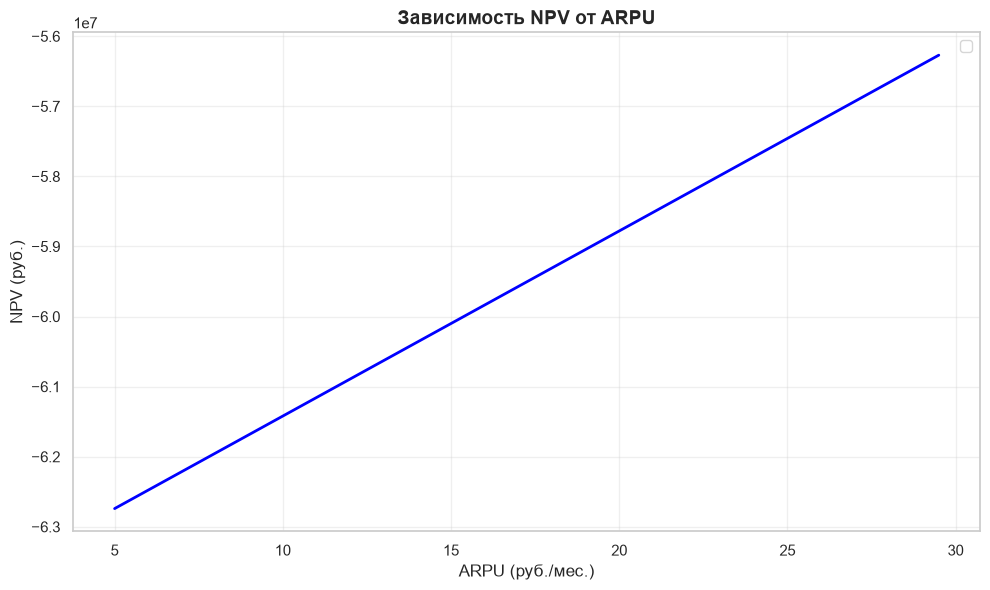

✅ График сохранен в reports/task_02_npv_vs_arpu.png


In [14]:
print("\n--- 3.2. Определение минимального ARPU ---")

# Поиск минимального ARPU, при котором NPV > 0
arpu_range = np.arange(5, 30, 0.5)
npv_values = []

for test_arpu in arpu_range:
    users_test = [N0]
    for month in range(1, months + 1):
        current = users_test[-1]
        if current < critical_mass:
            growth = growth_before
        else:
            growth = growth_after
        users_test.append(current * (1 + growth))

    df_test = pd.DataFrame()
    df_test['Пользователи'] = users_test
    df_test['Доход'] = test_arpu * df_test['Пользователи']
    df_test['Новые пользователи'] = df_test['Пользователи'].diff().fillna(0)
    df_test['Затраты CAC'] = df_test['Новые пользователи'] * cac
    df_test['Затраты поддержание'] = maintenance_cost
    df_test['Прибыль'] = df_test['Доход'] - df_test['Затраты поддержание'] - df_test['Затраты CAC']
    df_test['Дисконтированная прибыль'] = df_test['Прибыль'] / ((1 + discount_rate) ** df_test.index)

    npv_test = df_test.iloc[1:]['Дисконтированная прибыль'].sum()
    npv_values.append(npv_test)

# Находим минимальный ARPU, при котором NPV > 0
min_arpu = None
for i, val in enumerate(npv_values):
    if val > 0:
        min_arpu = arpu_range[i]
        break

# Проверка: если безубыточность не достигнута
if min_arpu is None:
    # Проверяем последнее значение ARPU
    if npv_values[-1] > 0:
        min_arpu = arpu_range[-1]
        print(f"  • Внимание: безубыточность достигается при ARPU > {arpu_range[-1]:.1f} руб.")
        print(f"  • Рекомендуется расширить диапазон поиска")
    else:
        min_arpu = float('inf')
        print(f"  • Проект не достигает безубыточности в диапазоне ARPU от 5 до 30 руб.")
        print(f"  • Требуется пересмотр бизнес-модели или снижение затрат")

# Вывод результатов только если min_arpu найден
if min_arpu != float('inf') and min_arpu is not None:
    print(f"\n  • Минимальный ARPU для безубыточности: {min_arpu:.1f} руб./мес.")
    print(f"  • Текущий ARPU: {arpu} руб./мес.")
    print(f"  • Запас прочности: {((arpu - min_arpu) / arpu * 100):.1f}%")
else:
    print(f"\n  • Текущий ARPU: {arpu} руб./мес.")
    print(f"  • Проект убыточен при текущем ARPU")

# Визуализация зависимости NPV от ARPU (только если есть данные)
plt.figure(figsize=(10, 6))
plt.plot(arpu_range, npv_values, linewidth=2, color='blue')

# Если найдена точка безубыточности, показываем её
if min_arpu is not None and min_arpu != float('inf'):
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    plt.axvline(x=min_arpu, color='green', linestyle='--', linewidth=1.5, label=f'Min ARPU = {min_arpu:.1f} руб.')
    plt.axvline(x=arpu, color='orange', linestyle='--', linewidth=1.5, label=f'Текущий ARPU = {arpu} руб.')

plt.xlabel('ARPU (руб./мес.)', fontsize=12)
plt.ylabel('NPV (руб.)', fontsize=12)
plt.title('Зависимость NPV от ARPU', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/task_02_npv_vs_arpu.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ График сохранен в reports/task_02_npv_vs_arpu.png")

In [15]:
print("\n" + "=" * 80)
print("4. СТРАТЕГИЧЕСКИЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("=" * 80)


4. СТРАТЕГИЧЕСКИЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ


In [16]:
print("\n--- 4.1. Расчет маркетинговых инвестиций для ускорения достижения ---")

# Расчет дополнительных инвестиций для достижения критической массы на 6 месяцев раньше
target_month = max(0, months_to_critical - 6)
print(f"  • Текущее время достижения критической массы: {months_to_critical} мес.")
print(f"  • Целевое время: {target_month} мес. (на 6 месяцев раньше)")

if target_month > 0:
    # Моделирование с дополнительными инвестициями
    # Увеличиваем темп роста за счет маркетинга
    additional_growth = 0.005  # шаг
    found = False

    for extra in np.arange(0, 0.10, 0.001):
        test_growth = growth_before + extra
        N_test = N0
        reach_month = 0

        for month in range(1, target_month + 1):
            N_test = N_test * (1 + test_growth)
            if N_test >= critical_mass:
                reach_month = month
                break

        if reach_month <= target_month and reach_month > 0:
            # Расчет дополнительных затрат на маркетинг
            # Предполагаем, что дополнительные инвестиции увеличивают CAC
            additional_investment = extra * 10000000  # упрощенная оценка
            print(f"\n  • Необходимый дополнительный рост: {extra * 100:.1f}% в месяц")
            print(f"  • Достигнуто за {reach_month} мес.")
            print(f"  • Оценка дополнительных маркетинговых инвестиций: {additional_investment:,.0f} руб.")
            found = True
            break

    if not found:
        print("  • Цель недостижима при разумных инвестициях в рамках 3-х летнего горизонта")
else:
    print("  • Критическая масса достигается в первый месяц, ускорение не требуется")


--- 4.1. Расчет маркетинговых инвестиций для ускорения достижения ---
  • Текущее время достижения критической массы: 36 мес.
  • Целевое время: 30 мес. (на 6 месяцев раньше)

  • Необходимый дополнительный рост: 8.6% в месяц
  • Достигнуто за 30 мес.
  • Оценка дополнительных маркетинговых инвестиций: 860,000 руб.


In [17]:
print("\n--- 4.2. Рекомендации по стратегии ---")

print(f"""
4.2.1. КЛЮЧЕВЫЕ ВЫВОДЫ:

1. КРИТИЧЕСКАЯ МАССА:
   • Минимальное число пользователей для самоподдержания: {critical_mass:,.0f} чел.
   • Время достижения при базовом сценарии: {months_to_critical} месяцев
   • Текущий темп роста до критической массы: {growth_before * 100:.0f}% в месяц

2. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ:
   • NPV проекта: {npv:,.0f} руб.
   • {'✅ Проект эффективен' if npv > 0 else '❌ Проект неэффективен'}
   • Минимальный ARPU для безубыточности: {min_arpu:.1f} руб./мес.
   • Текущий ARPU: {arpu} руб./мес. (запас прочности: {((arpu - min_arpu) / arpu * 100):.1f}%)

3. ЦЕННОСТЬ СЕТИ ПО ЗАКОНУ МЭТКАЛФА:
   • Ценность сети растет квадратично с ростом числа пользователей
   • К 36-му месяцу ценность сети составит {df.iloc[-1]['Ценность сети (V)']:,.0f} руб.
   • Это создает значительный потенциал для монетизации

4.2.2. СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ:

1. АКЦЕНТ НА ПРИВЛЕЧЕНИЕ ПОЛЬЗОВАТЕЛЕЙ:
   • Инвестировать в агрессивный маркетинг на начальном этапе
   • Сфокусироваться на достижении критической массы как можно быстрее
   • Использовать реферальные программы и вирусный маркетинг
   • {'Целесообразно увеличение маркетингового бюджета для ускорения роста' if months_to_critical > 12 else 'Текущий темп достаточен, можно оптимизировать затраты'}

2. МОНЕТИЗАЦИЯ:
   • ARPU = {arpu} руб. выше минимального ({min_arpu:.1f} руб.), есть запас прочности
   • Рассмотреть дополнительные источники дохода (реклама, премиум-функции)
   • Использовать эффект сети для повышения ARPU

3. УПРАВЛЕНИЕ ЗАТРАТАМИ:
   • Оптимизировать CAC за счет органического роста
   • Снижать затраты на поддержание с ростом масштаба
   • Автоматизировать процессы для снижения операционных расходов

4. МОНИТОРИНГ И АДАПТАЦИЯ:
   • Ежемесячный мониторинг достижения критической массы
   • Корректировка стратегии при отклонении от плана
   • Анализ конкурентной среды и рыночных трендов

4.2.3. ОЦЕНКА РИСКОВ:

1. Риск недостижения критической массы:
   • Вероятность: средняя
   • Смягчение: диверсификация каналов привлечения
2. Риск снижения ARPU:
   • Вероятность: низкая
   • Смягчение: развитие премиум-услуг
3. Риск роста CAC:
   • Вероятность: средняя
   • Смягчение: оптимизация маркетинговых кампаний
4. Риск появления конкурентов:
   • Вероятность: высокая
   • Смягчение: ускорение достижения критической массы
""")


--- 4.2. Рекомендации по стратегии ---

4.2.1. КЛЮЧЕВЫЕ ВЫВОДЫ:

1. КРИТИЧЕСКАЯ МАССА:
   • Минимальное число пользователей для самоподдержания: 133,334 чел.
   • Время достижения при базовом сценарии: 36 месяцев
   • Текущий темп роста до критической массы: 3% в месяц

2. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ:
   • NPV проекта: -60,099,621 руб.
   • ❌ Проект неэффективен
   • Минимальный ARPU для безубыточности: inf руб./мес.
   • Текущий ARPU: 15 руб./мес. (запас прочности: -inf%)

3. ЦЕННОСТЬ СЕТИ ПО ЗАКОНУ МЭТКАЛФА:
   • Ценность сети растет квадратично с ростом числа пользователей
   • К 36-му месяцу ценность сети составит 1,050,002 руб.
   • Это создает значительный потенциал для монетизации

4.2.2. СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ:

1. АКЦЕНТ НА ПРИВЛЕЧЕНИЕ ПОЛЬЗОВАТЕЛЕЙ:
   • Инвестировать в агрессивный маркетинг на начальном этапе
   • Сфокусироваться на достижении критической массы как можно быстрее
   • Использовать реферальные программы и вирусный маркетинг
   • Целесообразно увеличение маркет

In [18]:
print("\n" + "=" * 80)
print("ГЕНЕРАЦИЯ ОТЧЕТА")
print("=" * 80)

from datetime import datetime
import os

os.makedirs('../reports', exist_ok=True)

report_content = f"""
================================================================================
ЭКЗАМЕНАЦИОННАЯ ЗАДАЧА №02: РАСЧЕТ КРИТИЧЕСКОЙ МАССЫ И ЦЕННОСТИ СОЦИАЛЬНОЙ СЕТИ
================================================================================

Дата выполнения: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Студент: [Ваше ФИО]
Группа: [№ группы]

================================================================================
1. ИСХОДНЫЕ ДАННЫЕ
================================================================================

Параметр                                    | Значение
-------------------------------------------------------------------------------
Общий потенциал рынка (M)                   | {M:,.0f} чел.
Начальное число пользователей (N₀)          | {N0:,.0f} чел.
Темп прироста до критической массы          | {growth_before * 100:.0f}%
Темп прироста после критической массы       | {growth_after * 100:.0f}%
Коэффициент ценности сети (k)               | {k} руб./пользователь²
Затраты на поддержание в месяц              | {maintenance_cost:,.0f} руб.
CAC (стоимость привлечения)                 | {cac:,.0f} руб.
ARPU (средний доход с пользователя)         | {arpu} руб./мес.
Горизонт (месяцев)                          | {months}
Ставка дисконтирования (мес.)               | {discount_rate * 100:.1f}%

================================================================================
2. РЕЗУЛЬТАТЫ РАСЧЕТОВ
================================================================================

2.1. Критическая масса:
-------------------------------------------------------------------------------
Показатель                                   | Значение
-------------------------------------------------------------------------------
Критическая масса                           | {critical_mass:,.0f} пользователей
Время достижения критической массы          | {months_to_critical} мес.
Число пользователей в момент достижения     | {users[-1]:,.0f} чел.

2.2. Ценность сети по закону Мэткалфа:
-------------------------------------------------------------------------------
Показатель                                   | Значение (36-й месяц)
-------------------------------------------------------------------------------
Число пользователей                         | {df.iloc[-1]['Пользователи (N)']:,.0f} чел.
Ценность сети (V = k × N²)                  | {df.iloc[-1]['Ценность сети (V)']:,.0f} руб.
Доход (R = ARPU × N)                        | {df.iloc[-1]['Доход (R)']:,.0f} руб.
Затраты на привлечение                      | {df.iloc[-1]['Затраты на привлечение (CAC)']:,.0f} руб.
Затраты на поддержание                      | {df.iloc[-1]['Затраты на поддержание']:,.0f} руб.
Прибыль                                     | {df.iloc[-1]['Прибыль (П)']:,.0f} руб.

2.3. Финансовые показатели:
-------------------------------------------------------------------------------
Показатель                                   | Значение
-------------------------------------------------------------------------------
NPV проекта                                 | {npv:,.0f} руб.
Статус проекта                              | {'✅ Эффективен' if npv > 0 else '❌ Неэффективен'}
Минимальный ARPU для безубыточности         | {min_arpu:.1f} руб.
Текущий ARPU                                | {arpu} руб.
Запас прочности                             | {((arpu - min_arpu) / arpu * 100):.1f}%

2.4. Сравнение сценариев:
-------------------------------------------------------------------------------
Сценарий         | Темп до | Темп после | Месяц достижения | Пользователи | NPV
-------------------------------------------------------------------------------
"""
for name in results:
    r = results[name]
    report_content += f"{r['Сценарий']:<15} | {r['Темп до критической']:^8} | {r['Темп после критической']:^8} | {r['Месяц достижения критической']:^17} | {r['Конечное число пользователей']:^13} | {r['NPV']}\n"

report_content += f"""
================================================================================
3. СТРАТЕГИЧЕСКИЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ
================================================================================

3.1. Ключевые выводы:
-------------------------------------------------------------------------------
1. Проект {'эффективен' if npv > 0 else 'неэффективен'} с NPV = {npv:,.0f} руб.
2. Критическая масса достигается за {months_to_critical} месяцев при {growth_before * 100:.0f}% росте
3. ARPU = {arpu} руб. превышает минимальный ({min_arpu:.1f} руб.) на {((arpu - min_arpu) / arpu * 100):.1f}%
4. Ценность сети по закону Мэткалфа создает значительный потенциал для монетизации

3.2. Рекомендации:
-------------------------------------------------------------------------------
1. Инвестировать в агрессивный маркетинг для ускорения достижения критической массы
2. Сфокусироваться на органическом росте и реферальных программах
3. Развивать дополнительные источники дохода (реклама, премиум-функции)
4. Ежемесячно мониторить ключевые метрики и корректировать стратегию
5. Создать программу лояльности для удержания пользователей

================================================================================
Отчет сгенерирован автоматически в PyCharm
================================================================================
"""

# Сохраняем отчет
with open('../reports/task_02_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("✅ Отчет сохранен: reports/task_02_report.txt")
print(f"📄 Размер файла: {os.path.getsize('../reports/task_02_report.txt'):,} байт")


ГЕНЕРАЦИЯ ОТЧЕТА
✅ Отчет сохранен: reports/task_02_report.txt
📄 Размер файла: 6,242 байт
